# Credit Risk Scoring and Default Prediction

### *Author: Marzieh Safari*

#### Data Sources:
<a href="https://www.kaggle.com/datasets/adarshsng/lending-club-loan-data-csv?resource=download&select=loan.csv"> Lending Club Loan Data - Kaggle </a>

<a href="https://fred.stlouisfed.org/"> Federal Reserve Bank of St. Louis </a>

### Objectives:  

##### 1. Data Synthesis and Strategic Impact:  
- Synthesize complex behavioral and financial datasets into actionable intelligence to better understand customer default patterns.
- Quantitatively measure the model's impact on reducing capital risk and improving institutional decision-making.
  
##### 2. Predictive Modeling and Macroeconomic Integration:  
- Develop a predictive framework to estimate the probability of default by integrating borrower specific attributes with macroeconomic indicators sourced from the Federal Reserve.
-  Analyze the sensitivity of loan performance to external economic shifts, ensuring the model accounts for broader market volatility and credit cycles.

##### 3. Model Optimization and Selection:  
- Benchmark multiple classification algorithms to identify the optimal model based on a rigorous evaluation of Accuracy, AUC-ROC, and True Positive Rate (Recall).
- Prioritize the minimization of False Negatives to safeguard loan principal, while ensuring the model remains scalable for real-time classification of new credit applicants.


### Evaluation and Selection of Optimal Classification Models:  

The comparative analysis of various classification algorithms revealed that ExtraTrees and Random Forest classifiers consistently outperformed competing models across primary performance metrics, specifically in Classification Accuracy and the Area Under the Receiver Operating Characteristic Curve (AUC-ROC).

#### *Comparative Analysis of Model Performance:*
While both ensemble methods demonstrated high predictive power, a granular evaluation of the results favored the Random Forest architecture. The selection process was guided by the following technical observations:

**Metric Superiority:** Despite ExtraTrees yielding a marginally higher raw Accuracy, the Random Forest model exhibited superior values for Recall and AUC-ROC.

**ROC Dynamics:** The higher AUC-ROC indicates that Random Forest maintains a more robust balance between the True Positive Rate (Sensitivity) and the False Positive Rate (1-Specificity) across various decision thresholds.

**Artifact Preservation:** The optimized configurations for both models have been serialized as Pickle (.pkl) files. This facilitates further diagnostic deep-dives into their respective classification reports and confusion matrices.

#### *Business Impact and Risk Mitigation:*
The choice of Random Forest is driven by its ability to minimize False Negatives.

**Minimizing Principal Loss:** A False Negative represents a scenario where the model predicts a non-default, but the customer ultimately defaults. In such instances, the bank incurs a substantial loss on the loan principal. Random Forest’s lower False Negative rate directly mitigates this high capital risk.

**Evaluating Opportunity Cost:** Conversely, a False Positive occurs when a creditworthy customer is flagged as a default risk. While this results in a loss of potential interest income, it is secondary to the preservation of principal capital.

#### *Actionable Strategic Insights:*
The ultimate selection of a model necessitates a strategic trade-off between credit accessibility and capital preservation. To optimize this balance, I recommend the following:

**Principal vs. Interest Trade-off:** The modeling strategy prioritizes the prevention of large-scale principal loss over the marginal gain of interest income.

**Human-in-the-Loop Integration:** To mitigate the impact of False Positives, preventing the rejection of viable customers, a manual review process should be integrated. High-probability False Positive candidates should undergo secondary human verification to ensure the bank maintains a competitive customer acquisition rate without compromising its risk posture.

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r'D:\Data Science\python-codes\Projects\Banking\loan.csv')
df.head()

In [ ]:
df.info()

In [232]:
selected_cols = [
 'loan_amnt','int_rate','installment','emp_length','home_ownership',
 'annual_inc','issue_d','loan_status','dti',
 'delinq_2yrs', 'pub_rec', 'revol_util', 'addr_state', 'last_pymnt_d', 'term', 'chargeoff_within_12_mths'
]

df_selected = df[selected_cols].copy()
# Leave out Current loans for now, since we don't know if they will default or not
df_selected = df_selected[df_selected['loan_status'] != 'Current']

In [233]:
df_selected.head()

,loan_amnt,int_rate,installment,emp_length,home_ownership,annual_inc,issue_d,loan_status,dti,delinq_2yrs,pub_rec,revol_util,addr_state,last_pymnt_d,term,chargeoff_within_12_mths
100,30000,22.35,1151.16,5 years,MORTGAGE,100000.0,Dec-2018,Fully Paid,30.46,0.0,1.0,37.0,CA,Jan-2019,36 months,0.0
152,40000,16.14,975.71,< 1 year,MORTGAGE,45000.0,Dec-2018,Fully Paid,50.53,0.0,0.0,64.5,OH,Feb-2019,60 months,0.0
170,20000,7.56,622.68,10+ years,MORTGAGE,100000.0,Dec-2018,Fully Paid,18.92,0.0,0.0,29.9,WA,Feb-2019,36 months,0.0
186,4500,11.31,147.99,10+ years,RENT,38500.0,Dec-2018,Fully Paid,4.64,0.0,0.0,15.3,TX,Feb-2019,36 months,0.0
215,8425,27.27,345.18,3 years,MORTGAGE,450000.0,Dec-2018,Fully Paid,12.37,0.0,0.0,65.7,MA,Feb-2019,36 months,0.0


### Data Wrangling:

#### Dealing with Missing Values

In [234]:
df_selected['emp_length'] = df_selected['emp_length'].fillna('Unknown')
df_selected['annual_inc'] = df_selected['annual_inc'].fillna(df_selected['annual_inc'].median())
df_selected['dti'] = df_selected['dti'].fillna(df_selected['dti'].median())
df_selected = df_selected[df_selected['delinq_2yrs'].notnull()]  
df_selected = df_selected[df_selected['pub_rec'].notnull()]  
df_selected['revol_util'] = df_selected['revol_util'].fillna(df_selected['revol_util'].median())
df_selected = df_selected[df_selected['last_pymnt_d'].notnull()]  
df_selected = df_selected.dropna(subset=['chargeoff_within_12_mths'])

In [ ]:
df_selected.info()

In [ ]:
df_selected.isnull().sum()

#### Change data type:

In [235]:
cols = ['delinq_2yrs', 'pub_rec', 'chargeoff_within_12_mths']
df_selected[cols] = df_selected[cols].astype(int)

In [ ]:
df_selected.head()

#### Filter out data for the State of Ohio:

In [236]:
df_selected = df_selected[df_selected['addr_state'] == 'OH']
df_selected = df_selected.drop('last_pymnt_d', axis=1)
df_selected.head()

,loan_amnt,int_rate,installment,emp_length,home_ownership,annual_inc,issue_d,loan_status,dti,delinq_2yrs,pub_rec,revol_util,addr_state,term,chargeoff_within_12_mths
152,40000,16.14,975.71,< 1 year,MORTGAGE,45000.0,Dec-2018,Fully Paid,50.53,0,0,64.5,OH,60 months,0
402,1000,23.40,38.92,3 years,RENT,60000.0,Dec-2018,Fully Paid,20.78,0,0,72.8,OH,36 months,0
2593,3025,23.40,117.73,4 years,MORTGAGE,50000.0,Dec-2018,Fully Paid,11.76,0,0,12.1,OH,36 months,0
5890,10000,14.47,235.13,6 years,RENT,43000.0,Dec-2018,Fully Paid,29.97,0,1,35.7,OH,60 months,0
6064,13525,15.02,468.99,5 years,RENT,144000.0,Dec-2018,Fully Paid,26.78,1,0,27.7,OH,36 months,0


In [237]:
df_selected.shape

(43411, 15)

In [238]:
df_selected = df_selected[df_selected['annual_inc'] <= 2000000]

In [239]:
df_selected = df_selected[df_selected['pub_rec'] <= 75]

In [240]:
df_selected.shape

(43409, 15)

In [241]:
df_selected['loan_status'].value_counts()

loan_status
Fully Paid                                             33605
Charged Off                                             8774
Late (31-120 days)                                       552
In Grace Period                                          286
Late (16-30 days)                                         88
Does not meet the credit policy. Status:Fully Paid        84
Does not meet the credit policy. Status:Charged Off       18
Default                                                    2
Name: count, dtype: int64

In [242]:
bad_statuses = ['Charged Off', 'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)',
'Does not meet the credit policy. Status:Charged Off', 'Default' ] 

df_selected['target'] = df_selected['loan_status'].apply(lambda x: 1 if x in bad_statuses else 0)

print(df_selected['target'].value_counts(normalize=True))

target
0    0.776083
1    0.223917
Name: proportion, dtype: float64


In [243]:
df_selected.columns

Index(['loan_amnt', 'int_rate', 'installment', 'emp_length', 'home_ownership',
       'annual_inc', 'issue_d', 'loan_status', 'dti', 'delinq_2yrs', 'pub_rec',
       'revol_util', 'addr_state', 'term', 'chargeoff_within_12_mths',
       'target'],
      dtype='object')

In [244]:
df_selected = df_selected.drop('loan_status', axis=1)

In [245]:
categorical = ['emp_length', 'home_ownership', 'term']
numeric = df_selected.columns.drop(categorical + ['addr_state', 'target', 'issue_d']).tolist()

In [246]:
df_selected.shape

(43409, 15)

In [247]:
categorical

['emp_length', 'home_ownership', 'term']

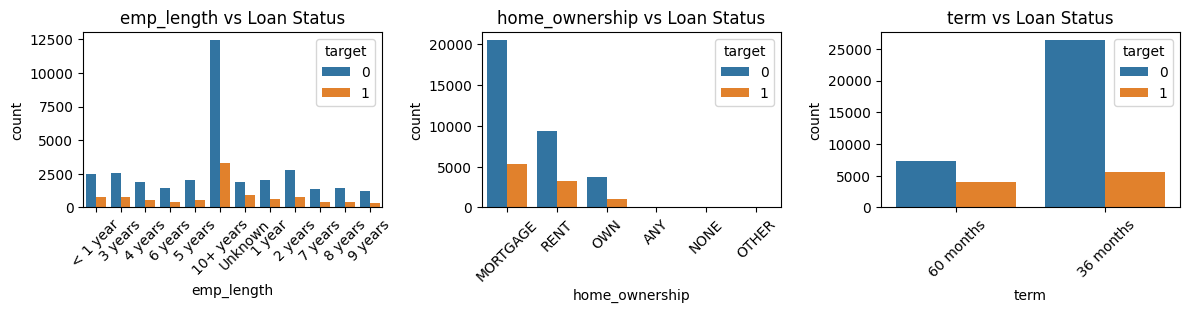

In [248]:
plt.figure(figsize=(12,8))
for i, col in enumerate(categorical):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=col, data=df_selected, hue='target')
    plt.title(f'{col} vs Loan Status')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [249]:
numeric

['loan_amnt',
 'int_rate',
 'installment',
 'annual_inc',
 'dti',
 'delinq_2yrs',
 'pub_rec',
 'revol_util',
 'chargeoff_within_12_mths']

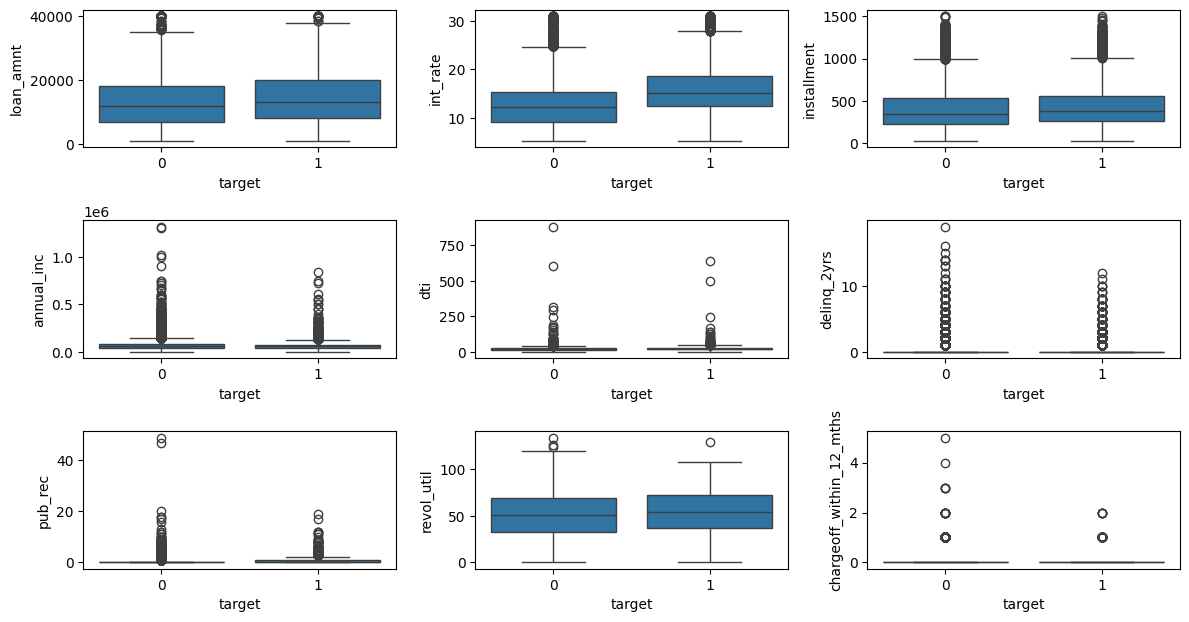

In [250]:
plt.figure(figsize=(12,8))
for i, col in enumerate(numeric):
    plt.subplot(4, 3, i+1)
    sns.boxplot(x='target', y=col, data=df_selected)
plt.tight_layout()
plt.show()

## Retreiving data from Federal Reserve Economic Data (FRED)

In [142]:
!pip install fredapi --quiet

In [192]:
# Get macroeconomic data from FRED with the fredapi 
from fredapi import Fred

fred = Fred(api_key='c4f1bd99bb93093449d2ff4af4d13eca')

series_ids = {
    'CPI': 'CPIAUCSL',
    'Fed_Funds_Rate': 'FEDFUNDS',
    'Ohio Unemployment Rate': 'OHUR'
}

data_dict = {name: fred.get_series(series_id) for name, series_id in series_ids.items()}

macro_df = pd.DataFrame(data_dict)
macro_df.index.name = 'Date'
macro_df = macro_df.dropna()

print(macro_df.head())
macro_df.info()

             CPI  Fed_Funds_Rate  Ohio Unemployment Rate
Date                                                    
1976-01-01  55.8            4.87                     8.1
1976-02-01  55.9            4.77                     8.1
1976-03-01  56.0            4.84                     8.1
1976-04-01  56.1            4.82                     7.9
1976-05-01  56.4            5.29                     7.8
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 599 entries, 1976-01-01 to 2025-12-01
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CPI                     599 non-null    float64
 1   Fed_Funds_Rate          599 non-null    float64
 2   Ohio Unemployment Rate  599 non-null    float64
dtypes: float64(3)
memory usage: 18.7 KB


In [ ]:
macro_df.head(10)

### Feature Engineering:

In [252]:
# See if unemployment 3 months ago predicts today's default
macro_df['Unemployment_lag3'] = macro_df['Ohio Unemployment Rate'].shift(3)

# See if the CHANGE in interest rates matters
macro_df['Fed_Funds_Diff'] = macro_df['Fed_Funds_Rate'].diff(periods=3).round(2)

macro_df.head(10)

,CPI,Fed_Funds_Rate,Ohio Unemployment Rate,Unemployment_lag3,Fed_Funds_Diff
Date,,,,,
1976-01-01,55.8,4.87,8.1,NaN,NaN
1976-02-01,55.9,4.77,8.1,NaN,NaN
1976-03-01,56.0,4.84,8.1,NaN,NaN
1976-04-01,56.1,4.82,7.9,8.1,-0.05
1976-05-01,56.4,5.29,7.8,8.1,0.52
1976-06-01,56.7,5.48,7.6,8.1,0.64
1976-07-01,57.0,5.31,7.5,7.9,0.49
1976-08-01,57.3,5.29,7.5,7.8,0.00
1976-09-01,57.6,5.25,7.4,7.6,-0.23


In [253]:
df_selected['issue_d'] = pd.to_datetime(df_selected['issue_d'], format='%b-%Y', errors='coerce')
df_merged = df_selected.merge(macro_df, left_on='issue_d', right_index=True, how='left')
df_merged.head()

df_merged.to_csv(r'D:\Data Science\python-codes\Projects\Banking\df_merged.csv', index=False)

In [ ]:
df_merged.describe(include=[float, int]).round(2)

In [ ]:
df_merged.describe(include=[object]).T

## Classification Models:

#### Importing libraries

In [254]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, log_loss, accuracy_score, ConfusionMatrixDisplay

### Preprocessing of data:

In [ ]:
# Define features and target variable
X = df_merged.drop(columns=['target', 'issue_d', 'addr_state', 'Fed_Funds_Rate', 'Ohio Unemployment Rate'])

categorical_features = ['emp_length', 'home_ownership', 'term']
numeric_features = X.columns.drop(categorical_features).tolist()

y = df_merged['target']


# Split data first (to avoid leakage)
df_merged = df_merged.sort_values('issue_d')
split_point = int(len(df_merged) * 0.8)
train_df = df_merged.iloc[:split_point]
test_df = df_merged.iloc[split_point:]

# Define X_train and X_test using drop list
drop_cols = ['target', 'issue_d', 'addr_state', 'Fed_Funds_Rate', 'Ohio Unemployment Rate']
X_train = train_df.drop(columns=drop_cols)
y_train = train_df['target']
X_test = test_df.drop(columns=drop_cols)
y_test = test_df['target']


# Initialize the transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# Return a Pandas DataFrame instead of a NumPy array
preprocessor.set_output(transform="pandas")

# Execute the transformation
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Strip forbidden characters [, ], and < from column names
X_train_transformed.columns = X_train_transformed.columns.str.replace('[', '', regex=False).str.replace(']', '', regex=False).str.replace('<', '', regex=False)
X_test_transformed.columns = X_test_transformed.columns.str.replace('[', '', regex=False).str.replace(']', '', regex=False).str.replace('<', '', regex=False)

# Verify the results
# print(X_train_transformed.head())


### Define a function to call for different models:

In [257]:
# Define a Function for models
def train_model(model, param_grid, X_train_transformed, X_test_transformed, y_train, y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train_transformed, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_transformed)
    acc = accuracy_score(y_test, y_pred)
    y_probs = best_model.predict_proba(X_test_transformed)[:, 1]
    auc_roc = roc_auc_score(y_test, y_probs)
    return best_model, acc, auc_roc, grid.best_params_

### XGBoost Classification:

In [258]:
# XGBoost model
xgb = XGBClassifier(random_state=42, scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(), eval_metric='logloss')

# Parameters for XGBoost
xgb_param_grid = {
    'n_estimators': [50, 100, 200], 
    'max_depth': [3, 5, 7], 
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1],
    'colsample_bytree': [0.8, 1]
}

In [259]:
# Get the best XGBoost model and its performance
best_xgb, acc_xgb, auc_roc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train_transformed, X_test_transformed, y_train, y_test)

In [260]:
print('XGBoost accuracy:', acc_xgb)
print('XGBoost AUC-ROC:', auc_roc_xgb)
print('Best XGBoost parameters:', params_xgb)

XGBoost accuracy: 0.4242110112877217
XGBoost AUC-ROC: 0.6774119809925504
Best XGBoost parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1}


### Disicion Tree Classification:

In [261]:
# Decision Tree model
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
# Parameters for Decision Tree
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [262]:
# Get the best Decision Tree model and its performance
best_dt, acc_dt, auc_roc_dt, params_dt = train_model(dt, dt_param_grid, X_train_transformed, X_test_transformed, y_train, y_test)

In [263]:
print('Decision Tree accuracy:', acc_dt)
print('Decision Tree AUC-ROC:', auc_roc_dt)
print('Best Decision Tree parameters:', params_dt)

Decision Tree accuracy: 0.3834369960838516
Decision Tree AUC-ROC: 0.6551967846187554
Best Decision Tree parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


### Random Forest Classification:

In [264]:
# Random Forest model
rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

# Parameters for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [265]:
# Get the best Random Forest model and its performance
best_rf, acc_rf, auc_roc_rf, params_rf = train_model(rf, rf_param_grid, X_train_transformed, X_test_transformed, y_train, y_test)   

In [266]:
print('Random Forest Tree accuracy:', acc_rf)
print('Random Forest Tree AUC-ROC:', auc_roc_rf)
print('Best Random Forest Tree parameters:', params_rf)

Random Forest Tree accuracy: 0.56496199032481
Random Forest Tree AUC-ROC: 0.6823296792835232
Best Random Forest Tree parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


### ExtraTree Classification:

In [267]:
# ExtraTrees model
et = ExtraTreesClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
# Parameters for ExtraTrees
et_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [268]:
# Get the best ExtraTrees model and its performance
best_et, acc_et, auc_roc_et, params_et = train_model(et, et_param_grid, X_train_transformed, X_test_transformed, y_train, y_test)

In [269]:
print('Extra Trees accuracy:', acc_et)
print('Extra Trees AUC-ROC:', auc_roc_et)
print('Best Extra Trees parameters:', params_et)

Extra Trees accuracy: 0.6467403824003686
Extra Trees AUC-ROC: 0.6705967216257669
Best Extra Trees parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


Among the classification models, Random Forest and ExtraTree models fit the data with higher AUC_ROC and Accuracy, their AUC-ROC was quite similar though they were different in term of Accuracy, thereby we will save both models as pickel files and apply their best parameters for results on Classification reports and confusion matrix.

In [270]:
best_et.predict(X_test_transformed)

array([1, 1, 0, ..., 0, 0, 1], shape=(8682,))

In [281]:
import pickle

# Save the model to a file
with open('credit_risk_model1.pkl', 'wb') as f:
    pickle.dump(best_et, f)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.69      0.74      6400
           1       0.38      0.53      0.44      2282

    accuracy                           0.65      8682
   macro avg       0.59      0.61      0.59      8682
weighted avg       0.69      0.65      0.66      8682

---- Metrics ---
Log Loss: 0.6675
AUC-ROC: 0.6706
--- Confusion Matrix ---
[[4401 1999]
 [1068 1214]]


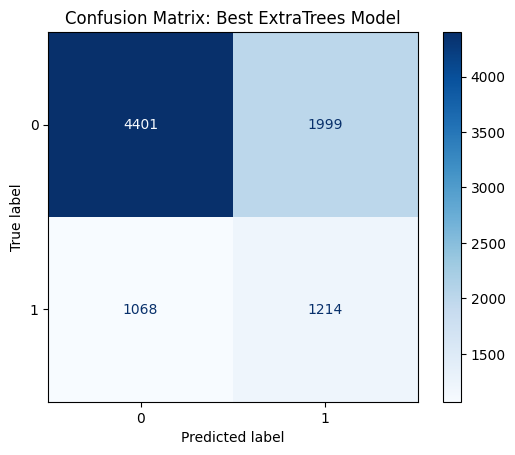

In [289]:
# Load the model back into memory
with open('credit_risk_model1.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Classification Report and Confusion Matrix for the best ExtraTrees model
y_pred = loaded_model.predict(X_test_transformed)
y_probs = loaded_model.predict_proba(X_test_transformed)[:, 1]

# Print the Reports
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Metrics
print("---- Metrics ---")
print(f"Log Loss: {log_loss(y_test, y_probs):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_probs):.4f}")


# Confusion Matrix
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualizations
dis = ConfusionMatrixDisplay(confusion_matrix=cm)
dis.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Best ExtraTrees Model")
plt.savefig('ExtraTrees Confusion Matrix.png')  # Save the figure
plt.show()


In [283]:
import pickle

# Save the model to a file
with open('credit_risk_model2.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.49      0.62      6400
           1       0.35      0.78      0.48      2282

    accuracy                           0.56      8682
   macro avg       0.61      0.63      0.55      8682
weighted avg       0.73      0.56      0.59      8682

---- Metrics ---
Log Loss: 0.6941
AUC-ROC: 0.6823
--- Confusion Matrix ---
[[3129 3271]
 [ 506 1776]]


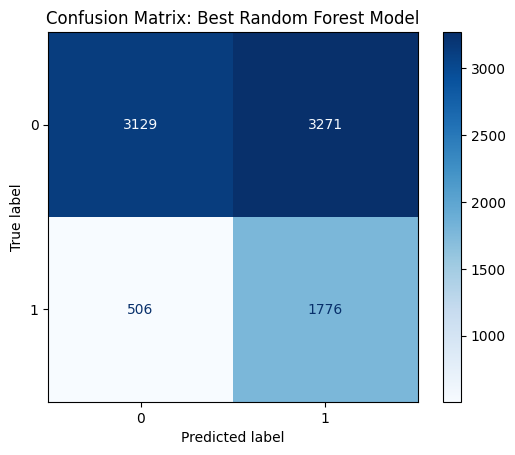

In [290]:
# Load the model back into memory
with open('credit_risk_model2.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Classification Report and Confusion Matrix for the best Random Forest model
y_pred = loaded_model.predict(X_test_transformed)
y_probs = loaded_model.predict_proba(X_test_transformed)[:, 1]

# Print the Reports
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Metrics
print("---- Metrics ---")
print(f"Log Loss: {log_loss(y_test, y_probs):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_probs):.4f}")


# Confusion Matrix
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualizations
dis = ConfusionMatrixDisplay(confusion_matrix=cm)
dis.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Best Random Forest Model")
plt.savefig('Random Forest Confusion Matrix.png')  # Save the figure
plt.show()